In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
df = pd.read_csv('students.csv')
df.head()

,name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
0,Alice,88,92,76,80,95,92,4.5,1
1,Bob,42,55,48,50,60,65,1.2,0
2,Charlie,75,70,80,68,88,85,3.0,1
3,Diana,95,98,91,89,97,98,6.0,1
4,Eve,38,42,50,45,55,58,0.8,0


In [27]:
print(df.shape)
print(df.dtypes)
df.describe()

(15, 9)
name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object


,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
count,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000
mean,65.000000,66.733333,66.200000,63.400000,74.800000,75.800000,2.893333,0.600000
std,20.060622,18.967893,17.773174,16.936014,16.657045,14.722189,1.658944,0.507093
min,30.000000,35.000000,40.000000,28.000000,45.000000,50.000000,0.500000,0.000000
25%,51.500000,53.500000,49.000000,53.500000,61.000000,63.500000,1.650000,0.000000
50%,65.000000,65.000000,70.000000,62.000000,75.000000,78.000000,2.800000,1.000000
75%,80.000000,77.000000,81.000000,73.500000,89.000000,86.500000,3.900000,1.000000
max,95.000000,98.000000,91.000000,92.000000,97.000000,98.000000,6.000000,1.000000


In [28]:
df['passed'].value_counts()

,count
passed,
1,9
0,6


In [29]:
subject_cols = ['math','science','english','history','pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

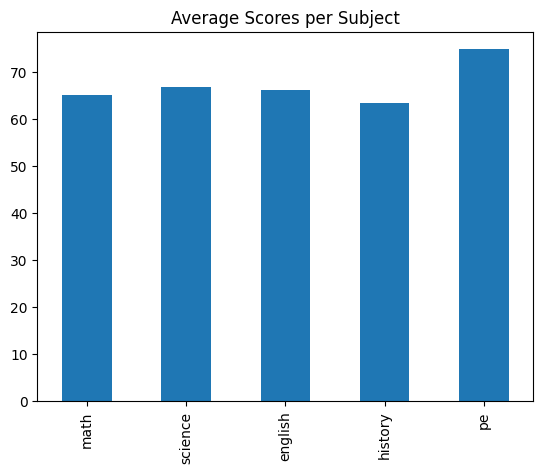

In [30]:
df[subject_cols].mean().plot(kind='bar')
plt.title("Average Scores per Subject")
plt.savefig('plot1_bar.png')
plt.show()

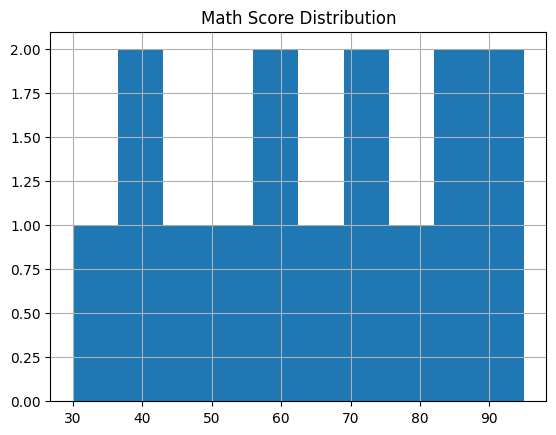

In [31]:
df['math'].hist()
plt.title("Math Score Distribution")
plt.savefig('plot2_hist.png')
plt.show()

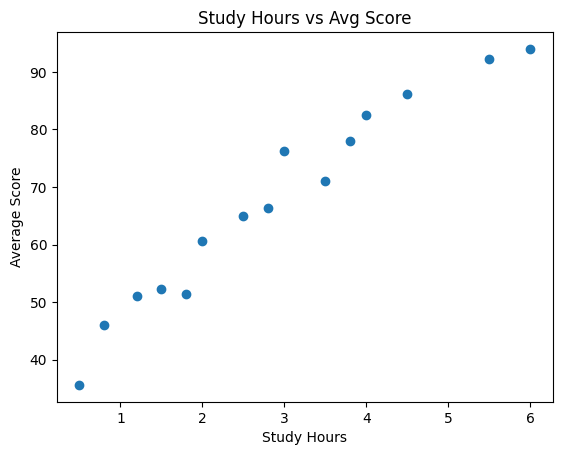

In [32]:
plt.scatter(df['study_hours_per_day'], df['avg_score'])
plt.xlabel("Study Hours")
plt.ylabel("Average Score")
plt.title("Study Hours vs Avg Score")
plt.savefig('plot3_scatter.png')
plt.show()

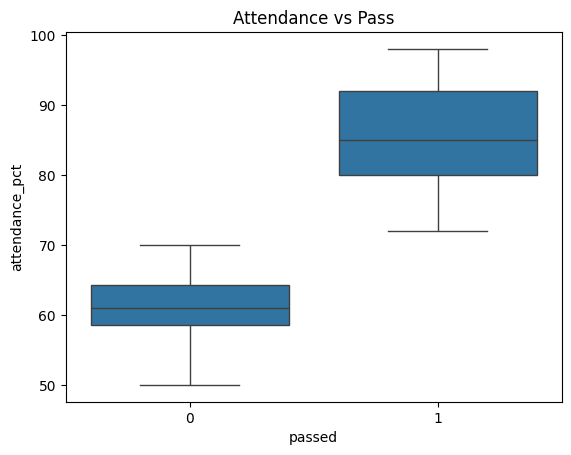

In [33]:
sns.boxplot(x='passed', y='attendance_pct', data=df)
plt.title("Attendance vs Pass")
plt.savefig('plot4_box.png')
plt.show()

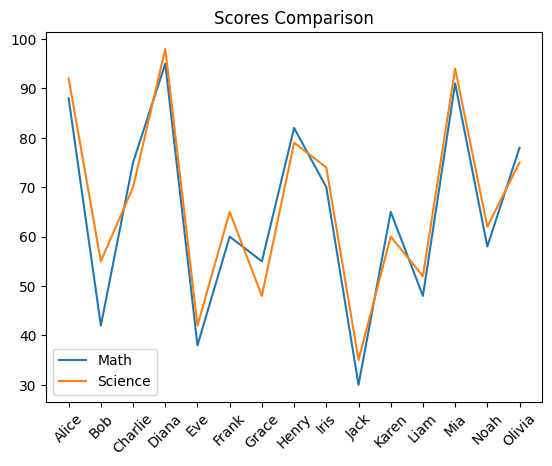

In [34]:
plt.plot(df['name'], df['math'], label='Math')
plt.plot(df['name'], df['science'], label='Science')
plt.xticks(rotation=45)
plt.legend()
plt.title("Scores Comparison")
plt.savefig('plot5_line.png')
plt.show()

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Features & Target
X = df[['math','science','english','history','pe','attendance_pct','study_hours_per_day']]
y = df['passed']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model
model = LogisticRegression()
model.fit(X_train, y_train)

# Accuracy
print("Train Accuracy:", model.score(X_train, y_train))
print("Test Accuracy:", model.score(X_test, y_test))

Train Accuracy: 1.0
Test Accuracy: 1.0


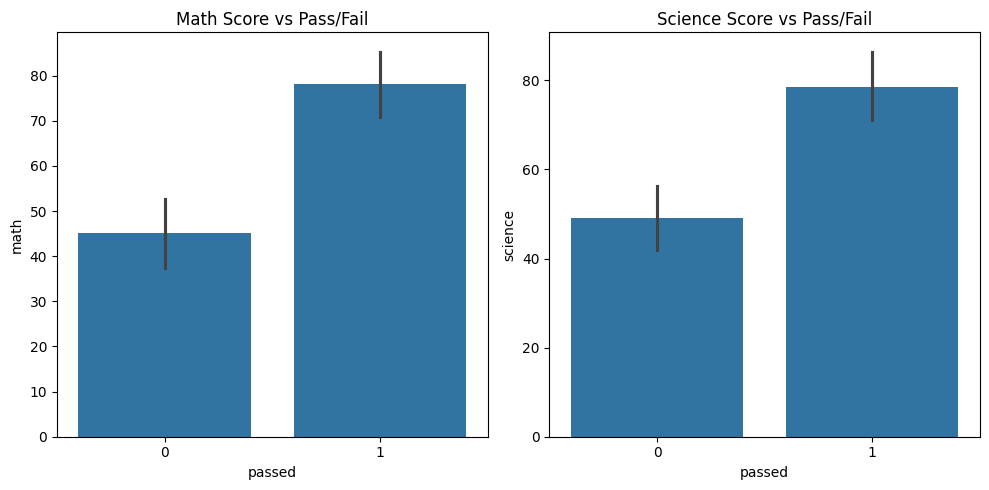

In [36]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.barplot(data=df, x='passed', y='math')
plt.title("Math Score vs Pass/Fail")

plt.subplot(1,2,2)
sns.barplot(data=df, x='passed', y='science')
plt.title("Science Score vs Pass/Fail")

plt.tight_layout()
plt.savefig('plot6_seaborn_bar.png')  # IMPORTANT
plt.show()

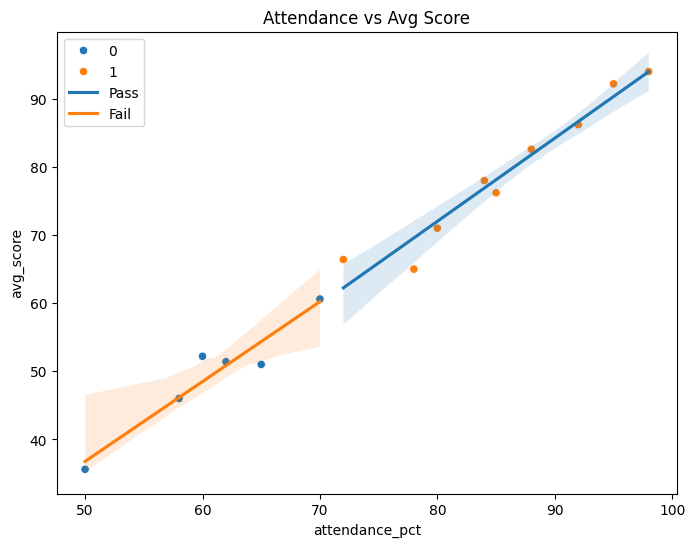

In [37]:
plt.figure(figsize=(8,6))

sns.scatterplot(data=df, x='attendance_pct', y='avg_score', hue='passed')

sns.regplot(data=df[df['passed']==1], x='attendance_pct', y='avg_score', scatter=False, label='Pass')
sns.regplot(data=df[df['passed']==0], x='attendance_pct', y='avg_score', scatter=False, label='Fail')

plt.title("Attendance vs Avg Score")
plt.legend()

plt.savefig('plot7_seaborn_scatter.png')  # IMPORTANT
plt.show()